In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import warnings
import matplotlib.pyplot as plt

#设置为seaborn风格
sns.set()
#不显示警告
warnings.filterwarnings("ignore")
plt.rcParams['font.sans-serif'] = ['SimHei']  #显示中文
plt.rcParams['axes.unicode_minus']=False #用来正常显示负号

In [4]:
#读取数据
data = pd.read_csv('data.csv')
data

,酒店名称,是否取消,提前预订天数,入住年份,入住月份,入住日期,周末过夜数,工作日过夜数,成人人数,儿童人数,...,押金类型,预订旅行社ID,预订公司/实体ID,等待天数,客户类型,客房日均价,车位需求数,特殊需求数,预订最终状态,预订最终状态更新日期
0,Resort Hotel,0,342,2015,July,1,0,0,2,0.0,...,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015/07/01
1,Resort Hotel,0,737,2015,July,1,0,0,2,0.0,...,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015/07/01
2,Resort Hotel,0,7,2015,July,1,0,1,1,0.0,...,No Deposit,NaN,NaN,0,Transient,75.00,0,0,Check-Out,2015/07/02
3,Resort Hotel,0,13,2015,July,1,0,1,1,0.0,...,No Deposit,304.0,NaN,0,Transient,75.00,0,0,Check-Out,2015/07/02
4,Resort Hotel,0,14,2015,July,1,0,2,2,0.0,...,No Deposit,240.0,NaN,0,Transient,98.00,0,1,Check-Out,2015/07/03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119385,City Hotel,0,23,2017,August,30,2,5,2,0.0,...,No Deposit,394.0,NaN,0,Transient,96.14,0,0,Check-Out,2017/09/06
119386,City Hotel,0,102,2017,August,31,2,5,3,0.0,...,No Deposit,9.0,NaN,0,Transient,225.43,0,2,Check-Out,2017/09/07
119387,City Hotel,0,34,2017,August,31,2,5,2,0.0,...,No Deposit,9.0,NaN,0,Transient,157.71,0,4,Check-Out,2017/09/07
119388,City Hotel,0,109,2017,August,31,2,5,2,0.0,...,No Deposit,89.0,NaN,0,Transient,104.40,0,0,Check-Out,2017/09/07


### 数据预处理

In [5]:
#重复值查看
print('去重前数据量：',len(data))
data.drop_duplicates(keep='first',inplace=True)
print('去重后数据量：',len(data))

去重前数据量： 119390
去重后数据量： 87390


In [6]:
#查看数据缺失值
for column in data.columns:
    #提取有缺失值的数据
    df_1 = data[data[column].isnull()]
    print(column,'缺失数据量为：',len(df_1),'缺失比例为：',len(df_1)/len(data))

酒店名称 缺失数据量为： 0 缺失比例为： 0.0
是否取消 缺失数据量为： 0 缺失比例为： 0.0
提前预订天数 缺失数据量为： 0 缺失比例为： 0.0
入住年份 缺失数据量为： 0 缺失比例为： 0.0
入住月份 缺失数据量为： 0 缺失比例为： 0.0
入住日期 缺失数据量为： 0 缺失比例为： 0.0
周末过夜数 缺失数据量为： 0 缺失比例为： 0.0
工作日过夜数 缺失数据量为： 0 缺失比例为： 0.0
成人人数 缺失数据量为： 0 缺失比例为： 0.0
儿童人数 缺失数据量为： 4 缺失比例为： 4.577182744021055e-05
婴儿人数 缺失数据量为： 0 缺失比例为： 0.0
餐食类型（BB早餐，HB午餐，FB晚餐，Undefined/SC无餐） 缺失数据量为： 0 缺失比例为： 0.0
客户来源国家 缺失数据量为： 452 缺失比例为： 0.005172216500743792
订单渠道 缺失数据量为： 0 缺失比例为： 0.0
是否是老客户 缺失数据量为： 0 缺失比例为： 0.0
历史取消预订的次数 缺失数据量为： 0 缺失比例为： 0.0
历史未取消预订的次数 缺失数据量为： 0 缺失比例为： 0.0
预定房间类型 缺失数据量为： 0 缺失比例为： 0.0
实际房间类型 缺失数据量为： 0 缺失比例为： 0.0
预定更改次数 缺失数据量为： 0 缺失比例为： 0.0
押金类型 缺失数据量为： 0 缺失比例为： 0.0
预订旅行社ID 缺失数据量为： 12187 缺失比例为： 0.1394553152534615
预订公司/实体ID 缺失数据量为： 82131 缺失比例为： 0.9398214898729832
等待天数 缺失数据量为： 0 缺失比例为： 0.0
客户类型 缺失数据量为： 0 缺失比例为： 0.0
客房日均价 缺失数据量为： 0 缺失比例为： 0.0
车位需求数 缺失数据量为： 0 缺失比例为： 0.0
特殊需求数 缺失数据量为： 0 缺失比例为： 0.0
预订最终状态 缺失数据量为： 0 缺失比例为： 0.0
预订最终状态更新日期 缺失数据量为： 0 缺失比例为： 0.0


In [7]:
#去掉不需要的数据，无效的和缺失比例过多的
data = data.drop(['是否取消','预订公司/实体ID'],axis = 1)
#进行缺失值填补
#儿童人数中位数填补
data['儿童人数'] = data['儿童人数'].fillna(data['儿童人数'].median())
#客户来源国家众数填补
data['客户来源国家'] = data['客户来源国家'].fillna(data['客户来源国家'].mode()[0])
#预订旅行社ID用0填补
data['预订旅行社ID'] = data['预订旅行社ID'].fillna(0)

In [8]:
#修改数据的类型
data['儿童人数'] = data['儿童人数'].astype(int)
data['预订旅行社ID'] = data['预订旅行社ID'].astype(int)

In [9]:
#替换餐饮情况
data['餐食类型（BB早餐，HB午餐，FB晚餐，Undefined/SC无餐）'] = data['餐食类型（BB早餐，HB午餐，FB晚餐，Undefined/SC无餐）'].replace("Undefined", "SC")

In [10]:
#去除没有入住人数的数据
data = data.drop(data.index[list(data["成人人数"] + data["儿童人数"] + data["婴儿人数"] == 0)])
data

,酒店名称,提前预订天数,入住年份,入住月份,入住日期,周末过夜数,工作日过夜数,成人人数,儿童人数,婴儿人数,...,预定更改次数,押金类型,预订旅行社ID,等待天数,客户类型,客房日均价,车位需求数,特殊需求数,预订最终状态,预订最终状态更新日期
0,Resort Hotel,342,2015,July,1,0,0,2,0,0,...,3,No Deposit,0,0,Transient,0.00,0,0,Check-Out,2015/07/01
1,Resort Hotel,737,2015,July,1,0,0,2,0,0,...,4,No Deposit,0,0,Transient,0.00,0,0,Check-Out,2015/07/01
2,Resort Hotel,7,2015,July,1,0,1,1,0,0,...,0,No Deposit,0,0,Transient,75.00,0,0,Check-Out,2015/07/02
3,Resort Hotel,13,2015,July,1,0,1,1,0,0,...,0,No Deposit,304,0,Transient,75.00,0,0,Check-Out,2015/07/02
4,Resort Hotel,14,2015,July,1,0,2,2,0,0,...,0,No Deposit,240,0,Transient,98.00,0,1,Check-Out,2015/07/03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119385,City Hotel,23,2017,August,30,2,5,2,0,0,...,0,No Deposit,394,0,Transient,96.14,0,0,Check-Out,2017/09/06
119386,City Hotel,102,2017,August,31,2,5,3,0,0,...,0,No Deposit,9,0,Transient,225.43,0,2,Check-Out,2017/09/07
119387,City Hotel,34,2017,August,31,2,5,2,0,0,...,0,No Deposit,9,0,Transient,157.71,0,4,Check-Out,2017/09/07
119388,City Hotel,109,2017,August,31,2,5,2,0,0,...,0,No Deposit,89,0,Transient,104.40,0,0,Check-Out,2017/09/07


### 数据探索

#### 数值型数据

In [11]:
num_feas = ['提前预订天数', '入住年份', '入住日期', '周末过夜数', '工作日过夜数', '成人人数', '儿童人数', '婴儿人数',
       '是否是老客户', '历史取消预订的次数', '历史未取消预订的次数', '预定更改次数', '预订旅行社ID', '等待天数',
       '客房日均价', '车位需求数', '特殊需求数']
#查看基本描述性统计
data[num_feas].describe().T

,count,mean,std,min,25%,50%,75%,max
提前预订天数,87224.0,79.976486,86.059119,0.00,11.00,49.0,125.0,737.0
入住年份,87224.0,2016.210378,0.686073,2015.00,2016.00,2016.0,2017.0,2017.0
入住日期,87224.0,15.815544,8.835550,1.00,8.00,16.0,23.0,31.0
周末过夜数,87224.0,1.004666,1.027416,0.00,0.00,1.0,2.0,19.0
工作日过夜数,87224.0,2.624048,2.039844,0.00,1.00,2.0,4.0,50.0
成人人数,87224.0,1.879414,0.621710,0.00,2.00,2.0,2.0,55.0
儿童人数,87224.0,0.138907,0.456279,0.00,0.00,0.0,0.0,10.0
婴儿人数,87224.0,0.010846,0.113707,0.00,0.00,0.0,0.0,10.0
是否是老客户,87224.0,0.038567,0.192563,0.00,0.00,0.0,0.0,1.0
历史取消预订的次数,87224.0,0.030404,0.369357,0.00,0.00,0.0,0.0,26.0


数值型特征个数： 17


<bound method Figure.tight_layout of <Figure size 1080x1728 with 18 Axes>>

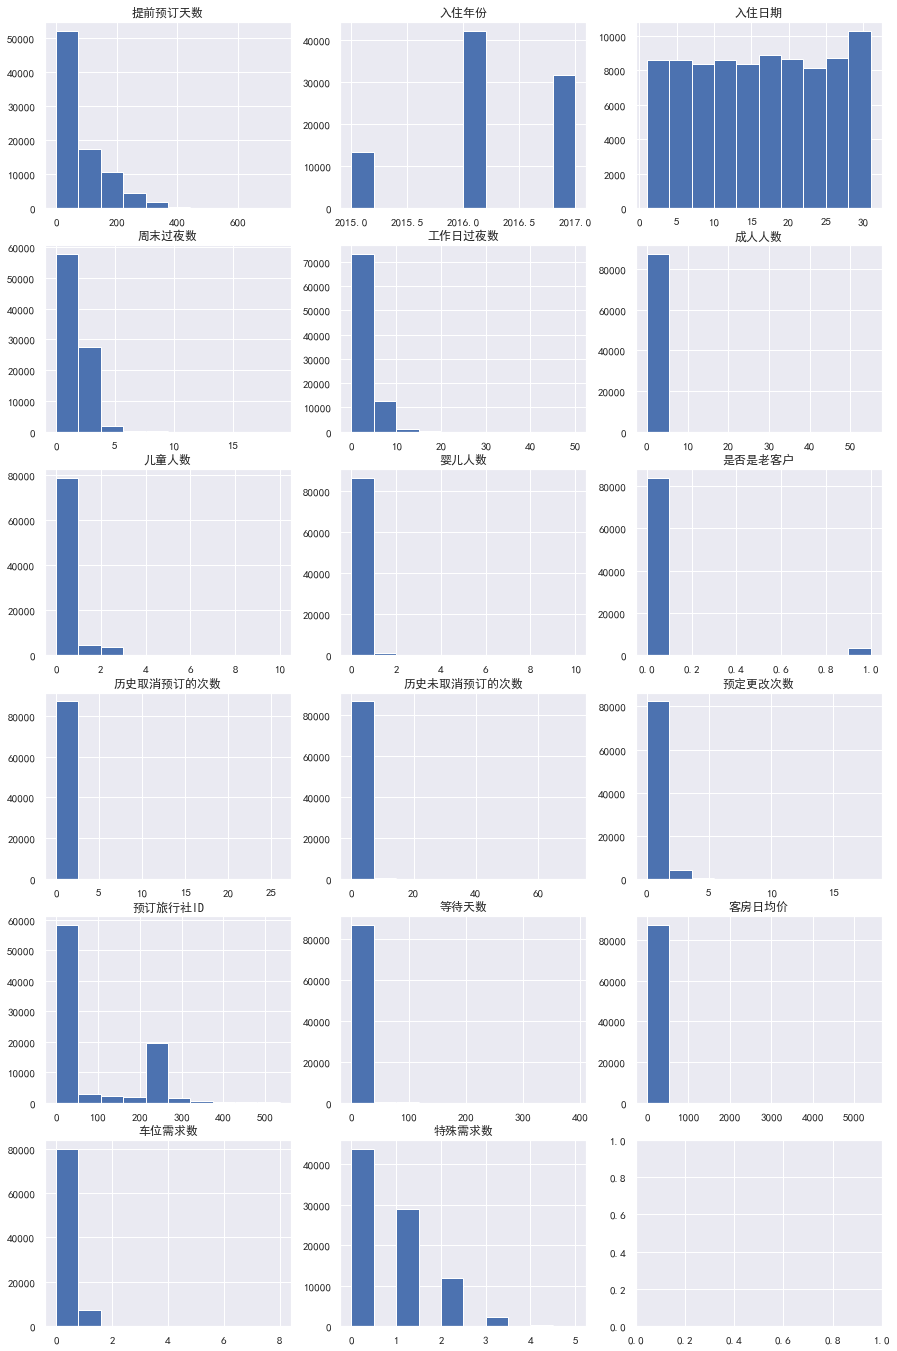

In [12]:
#绘制各个数值型特征的分布情况
#计算数值型特征的维度数，方便规划长宽比例
k = len(num_feas)
print('数值型特征个数：',k)
n = 3 #每行三个
m =  6#一共设置6行

#设置画布，规划图的个数排版
fig,axes = plt.subplots(m,n,figsize = (n*5,m*4))
for i in range(k):
    column = num_feas[i]
    r,c = i//n,i%n#计算第几幅图
    ax = axes[r,c]
    data[column].hist(ax = ax)#绘制分布直方图
    ax.set_title(column)
fig.tight_layout#自动调整子图参数

In [13]:
#去掉日均价过高的数据和小于0的数据
data = data[data['客房日均价'].map(lambda x:0 < x < 5000)]

#### 类别型特征

In [14]:
#类别特征
label_feas = [c for c in list(data.columns) if c not in num_feas] 
## 查看类别特征的分布情况
for col in label_feas:
    #计算每个类型的个数
    display(pd.value_counts(data[col]))
    print("========")

City Hotel      52316
Resort Hotel    33263
Name: 酒店名称, dtype: int64

August       11099
July          9899
May           8208
April         7785
June          7650
March         7364
October       6728
September     6538
February      5955
December      4940
November      4843
January       4570
Name: 入住月份, dtype: int64

BB    66578
SC     9721
HB     8936
FB      344
Name: 餐食类型（BB早餐，HB午餐，FB晚餐，Undefined/SC无餐）, dtype: int64

PRT    26458
GBR    10359
FRA     8785
ESP     7181
DEU     5364
       ...  
LCA        1
CYM        1
MMR        1
BHS        1
SMR        1
Name: 客户来源国家, Length: 177, dtype: int64

TA/TO        68279
Direct       12214
Corporate     4904
GDS            177
Undefined        5
Name: 订单渠道, dtype: int64

...

A    45580
D    22136
E     7084
F     3526
G     2403
C     2118
B     1756
H      694
I      160
K      121
L        1
Name: 实际房间类型, dtype: int64

No Deposit    84435
Non Refund     1037
Refundable      107
Name: 押金类型, dtype: int64

Transient          70603
Transient-Party    11351
Contract            3115
Group                510
Name: 客户类型, dtype: int64

Check-Out    61742
Canceled     22848
No-Show        989
Name: 预订最终状态, dtype: int64

2016/02/14    207
2017/05/25    199
2016/03/28    193
2015/10/21    193
2016/10/06    192
             ... 
2015/01/02      1
2015/01/28      1
2015/03/13      1
2015/03/18      1
2015/04/21      1
Name: 预订最终状态更新日期, Length: 924, dtype: int64

In [15]:
#去掉预定状态no-show的数据
data = data[data['预订最终状态']!='No-Show']

### 建模

#### 特征处理

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,roc_auc_score
from sklearn.metrics import confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV  #调参工具
from sklearn.metrics import make_scorer
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression

In [17]:
#待划分样本数据的结果（标签）
YS = data['预订最终状态'].map({'Check-Out':0,'Canceled':1})
#待划分样本数据
XS = data.drop(['预订最终状态'],axis = 1)
#筛选出类别数据与数值型数据
label_feas = [c for c in list(data.columns) if c not in num_feas] 
label_feass = [l for l in label_feas if l != '预订最终状态']
df1 = XS[label_feass]
df2 = XS[num_feas]

In [18]:
from collections import Counter
Counter(YS)

Counter({0: 61742, 1: 22848})

In [19]:
#对类别数据进行独热编码
df_1 = pd.get_dummies(df1)
df_1

,酒店名称_City Hotel,酒店名称_Resort Hotel,入住月份_April,入住月份_August,入住月份_December,入住月份_February,入住月份_January,入住月份_July,入住月份_June,入住月份_March,...,预订最终状态更新日期_2017/09/03,预订最终状态更新日期_2017/09/04,预订最终状态更新日期_2017/09/05,预订最终状态更新日期_2017/09/06,预订最终状态更新日期_2017/09/07,预订最终状态更新日期_2017/09/08,预订最终状态更新日期_2017/09/09,预订最终状态更新日期_2017/09/10,预订最终状态更新日期_2017/09/12,预订最终状态更新日期_2017/09/14
2,0,1,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,1,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,1,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
6,0,1,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
7,0,1,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119385,1,0,0,1,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
119386,1,0,0,1,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
119387,1,0,0,1,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
119388,1,0,0,1,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0


In [20]:
#对数值型数据进行标准化处理
df2 = (df2 - df2.mean()) / df2.std()
df2

,提前预订天数,入住年份,入住日期,周末过夜数,工作日过夜数,成人人数,儿童人数,婴儿人数,是否是老客户,历史取消预订的次数,历史未取消预订的次数,预定更改次数,预订旅行社ID,等待天数,客房日均价,车位需求数,特殊需求数
2,-0.860127,-1.776703,-1.677731,-0.992822,-0.817243,-1.763953,-0.306484,-0.094858,-0.18774,-0.079682,-0.100897,-0.377761,-0.741978,-0.074602,-0.668008,-0.302034,-0.843594
3,-0.790423,-1.776703,-1.677731,-0.992822,-0.817243,-1.763953,-0.306484,-0.094858,-0.18774,-0.079682,-0.100897,-0.377761,2.016565,-0.074602,-0.668008,-0.302034,-0.843594
4,-0.778805,-1.776703,-1.677731,-0.992822,-0.322049,0.233033,-0.306484,-0.094858,-0.18774,-0.079682,-0.100897,-0.377761,1.435819,-0.074602,-0.210474,-0.302034,0.359184
6,-0.941449,-1.776703,-1.677731,-0.992822,-0.322049,0.233033,-0.306484,-0.094858,-0.18774,-0.079682,-0.100897,-0.377761,-0.741978,-0.074602,-0.031438,-0.302034,-0.843594
7,-0.836892,-1.776703,-1.677731,-0.992822,-0.322049,0.233033,-0.306484,-0.094858,-0.18774,-0.079682,-0.100897,-0.377761,2.007490,-0.074602,-0.111010,-0.302034,0.359184
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119385,-0.674249,1.144184,1.605152,0.962404,1.163534,0.233033,-0.306484,-0.094858,-0.18774,-0.079682,-0.100897,-0.377761,2.833238,-0.074602,-0.247474,-0.302034,-0.843594
119386,0.243525,1.144184,1.718355,0.962404,1.163534,2.230019,-0.306484,-0.094858,-0.18774,-0.079682,-0.100897,-0.377761,-0.660311,-0.074602,2.324468,-0.302034,1.561962
119387,-0.546458,1.144184,1.718355,0.962404,1.163534,0.233033,-0.306484,-0.094858,-0.18774,-0.079682,-0.100897,-0.377761,-0.660311,-0.074602,0.977326,-0.302034,3.967517
119388,0.324846,1.144184,1.718355,0.962404,1.163534,0.233033,-0.306484,-0.094858,-0.18774,-0.079682,-0.100897,-0.377761,0.065622,-0.074602,-0.083160,-0.302034,-0.843594


In [21]:
#重命名索引
df_1.index = list(range(len(df_1)))
df2.index = list(range(len(df2)))
#合并数据
XS = pd.merge(df_1,df2,left_index = True,right_index = True)
XS

,酒店名称_City Hotel,酒店名称_Resort Hotel,入住月份_April,入住月份_August,入住月份_December,入住月份_February,入住月份_January,入住月份_July,入住月份_June,入住月份_March,...,婴儿人数,是否是老客户,历史取消预订的次数,历史未取消预订的次数,预定更改次数,预订旅行社ID,等待天数,客房日均价,车位需求数,特殊需求数
0,0,1,0,0,0,0,0,1,0,0,...,-0.094858,-0.18774,-0.079682,-0.100897,-0.377761,-0.741978,-0.074602,-0.668008,-0.302034,-0.843594
1,0,1,0,0,0,0,0,1,0,0,...,-0.094858,-0.18774,-0.079682,-0.100897,-0.377761,2.016565,-0.074602,-0.668008,-0.302034,-0.843594
2,0,1,0,0,0,0,0,1,0,0,...,-0.094858,-0.18774,-0.079682,-0.100897,-0.377761,1.435819,-0.074602,-0.210474,-0.302034,0.359184
3,0,1,0,0,0,0,0,1,0,0,...,-0.094858,-0.18774,-0.079682,-0.100897,-0.377761,-0.741978,-0.074602,-0.031438,-0.302034,-0.843594
4,0,1,0,0,0,0,0,1,0,0,...,-0.094858,-0.18774,-0.079682,-0.100897,-0.377761,2.007490,-0.074602,-0.111010,-0.302034,0.359184
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84585,1,0,0,1,0,0,0,0,0,0,...,-0.094858,-0.18774,-0.079682,-0.100897,-0.377761,2.833238,-0.074602,-0.247474,-0.302034,-0.843594
84586,1,0,0,1,0,0,0,0,0,0,...,-0.094858,-0.18774,-0.079682,-0.100897,-0.377761,-0.660311,-0.074602,2.324468,-0.302034,1.561962
84587,1,0,0,1,0,0,0,0,0,0,...,-0.094858,-0.18774,-0.079682,-0.100897,-0.377761,-0.660311,-0.074602,0.977326,-0.302034,3.967517
84588,1,0,0,1,0,0,0,0,0,0,...,-0.094858,-0.18774,-0.079682,-0.100897,-0.377761,0.065622,-0.074602,-0.083160,-0.302034,-0.843594


In [22]:
#随机划分训练样本数据为训练接和验证集
X_train,X_test,y_train,y_test = train_test_split(XS,YS,test_size=0.3,random_state = 0,stratify = YS)

#随机森林判断特征的重要性
rf = RandomForestClassifier(n_estimators=100,max_depth=10,verbose=1)
rf.fit(X_train,y_train)

[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    8.6s finished


RandomForestClassifier(max_depth=10, verbose=1)

In [23]:
# 基于模型的特征重要性评估
# 得到特征重要性
importances = list(rf.feature_importances_)
# 转换格式
feature_importances = [(feature, importance) for feature, importance in zip(list(XS.columns), importances)]
# 排序
feature_importances = sorted(feature_importances, key = lambda x: x[1], reverse = True)
# 输出展示
result = ['Variable: {:10} Importance: {}'.format(*pair) for pair in feature_importances]
result

['Variable: 提前预订天数     Importance: 0.09234257269245749',
 'Variable: 车位需求数      Importance: 0.07206617812736978',
 'Variable: 特殊需求数      Importance: 0.053780264783746506',
 'Variable: 客户来源国家_PRT Importance: 0.053632039395698314',
 'Variable: 押金类型_Non Refund Importance: 0.052884975008071294',
 'Variable: 预订旅行社ID    Importance: 0.05247011038369468',
 'Variable: 客户类型_Transient Importance: 0.05055224454532384',
 'Variable: 历史取消预订的次数  Importance: 0.049642789418306625',
 'Variable: 订单渠道_TA/TO Importance: 0.04382073008542421',
 'Variable: 客房日均价      Importance: 0.03619340455086519',
 'Variable: 预定更改次数     Importance: 0.03182983060038381',
 'Variable: 押金类型_No Deposit Importance: 0.031725929296043315',
 'Variable: 客户类型_Transient-Party Importance: 0.02908798820128746',
 'Variable: 订单渠道_Direct Importance: 0.02522753494961188',
 'Variable: 历史未取消预订的次数 Importance: 0.01928505876965553',
 'Variable: 工作日过夜数     Importance: 0.018580151344322796',
 'Variable: 入住年份       Importance: 0.016453301180145024',

In [24]:
#筛选特征重要性大于0的
feas = [f[0] for f in feature_importances if f[1] > 0]
X_train = X_train[feas]
X_test = X_test[feas]

In [25]:
X_train

,提前预订天数,车位需求数,特殊需求数,客户来源国家_PRT,押金类型_Non Refund,预订旅行社ID,客户类型_Transient,历史取消预订的次数,订单渠道_TA/TO,客房日均价,...,预订最终状态更新日期_2016/12/01,预订最终状态更新日期_2015/10/07,预订最终状态更新日期_2015/01/30,客户来源国家_TUN,客户来源国家_TWN,预订最终状态更新日期_2016/06/19,预订最终状态更新日期_2017/08/14,预订最终状态更新日期_2016/06/11,预订最终状态更新日期_2016/11/28,预订最终状态更新日期_2017/07/29
7803,-0.186319,-0.302034,-0.843594,1,0,2.107306,1,-0.079682,1,-0.097482,...,0,0,0,0,0,0,0,0,0,0
39587,-0.267640,-0.302034,-0.843594,0,0,-0.660311,1,-0.079682,1,0.149586,...,0,0,0,0,0,0,0,0,0,0
18864,0.231907,3.220514,0.359184,0,0,1.435819,1,-0.079682,1,-0.290045,...,0,0,0,0,0,0,0,0,0,0
81683,-0.151467,-0.302034,1.561962,0,0,-0.741978,1,-0.079682,0,-0.011545,...,0,0,0,0,0,0,0,0,0,0
17433,-0.104997,-0.302034,0.359184,1,0,1.526560,1,-0.079682,0,0.346525,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65459,1.289089,-0.302034,-0.843594,0,0,-0.415309,0,-0.079682,1,-0.170688,...,0,0,0,0,0,0,0,0,0,0
55763,-0.778805,3.220514,0.359184,0,0,-0.660311,1,-0.079682,1,0.590212,...,0,0,0,0,0,0,0,0,0,0
64787,1.010272,-0.302034,1.561962,0,0,-0.596792,1,-0.079682,1,-0.029449,...,0,0,0,0,0,0,0,0,0,0
56925,-0.883362,-0.302034,1.561962,1,0,-0.741978,1,-0.079682,0,-0.866937,...,0,0,0,0,0,0,0,0,0,0


#### 搭建模型

#### 逻辑回归

In [26]:
#逻辑回归
lr = LogisticRegression(solver='liblinear', class_weight="balanced")
lr.fit(X_train,y_train)

LogisticRegression(class_weight='balanced', solver='liblinear')

In [27]:
#计算训练集准确率
lr.score(X_train,y_train)

0.8111901102798372

In [28]:
#计算测试集准确率
lr.score(X_test,y_test)

0.8026953540607636

#### 贝叶斯

In [26]:
#贝叶斯
gb = GaussianNB()
gb.fit(X_train,y_train)

GaussianNB()

In [27]:
#计算训练集准确率
gb.score(X_train,y_train)

0.752503673179876

In [28]:
#计算测试集准确率
gb.score(X_test,y_test)

0.737794065492375

#### 随机森林

In [58]:
import time
#随机森林
#计时
start_time = time.time()
#实例化随机森林模型
rfr = RandomForestClassifier(class_weight="balanced",random_state = 10)
#确定调节的参数
param_grid_lr = {'n_estimators':list(range(100,500,50)),'max_depth':list(range(20,60,10)),'min_samples_split':list(range(2,10,3)),'min_samples_leaf':list(range(3,10,2))}
#随机网格搜索调参
gs_rfr = RandomizedSearchCV(estimator=rfr,param_distributions=param_grid_lr,cv=5,
                    scoring=make_scorer(accuracy_score))
#训练模型
gs_rfr.fit(X_train,y_train)
print(gs_rfr.best_score_)
print(gs_rfr.best_params_)
end_time = time.time()
print("随机网格搜索经历时间：%.3f S" % float(end_time-start_time))

0.8218973000682821
{'n_estimators': 450, 'min_samples_split': 5, 'min_samples_leaf': 3, 'max_depth': 50}
随机网格搜索经历时间：6111.903 S


In [59]:
#计算训练集准确率
gs_rfr.score(X_train,y_train)

0.8526168240082415

In [60]:
#计算测试集准确率
gs_rfr.score(X_test,y_test)

0.8257871300784174

#### 决策树

In [32]:
#决策树
#计时
start_time = time.time()
#实例化决策树模型
dr = DecisionTreeClassifier()
#确定调节的参数
param_grid_lr = {'max_depth':list(range(50,200,30)),'max_leaf_nodes':list(range(10,50,4))}
#随机网格搜索调参
gs_dr = RandomizedSearchCV(estimator=dr,param_distributions=param_grid_lr,cv=5,
                    scoring=make_scorer(accuracy_score))
#训练模型
gs_dr.fit(X_train,y_train)
print(gs_dr.best_score_)
print(gs_dr.best_params_)
end_time = time.time()
print("随机网格搜索经历时间：%.3f S" % float(end_time-start_time))

0.8289564463442588
{'max_leaf_nodes': 46, 'max_depth': 80}
随机网格搜索经历时间：256.759 S


In [33]:
#计算训练集准确率
gs_dr.score(X_train,y_train)

0.8307804029520545

In [34]:
#计算测试集准确率
gs_dr.score(X_test,y_test)

0.8288213736848328

### 模型评价

In [35]:
# 分类模型测试集上效果
# auc和混淆矩阵评估
def get_score(model,name):
    #对训练集和测试集进行预测并且生成属于1类的概率
    y_train_pred_clf = model.predict_proba(X_train)
    y_train_pred = model.predict(X_train)
    y_test_pred_clf = model.predict_proba(X_test)
    y_test_pred = model.predict(X_test)
    #计算训练集和测试集上的AUC与准确率
    auc_train = roc_auc_score(y_train,y_train_pred_clf[:,1])
    auc_test = roc_auc_score(y_test,y_test_pred_clf[:,1])
    acc_train = accuracy_score(y_train,y_train_pred)
    acc_test = accuracy_score(y_test,y_test_pred)
    #生成结果存入
    df = pd.DataFrame()
    df['指标'] = ['AUC','ACC']
    df['训练集'] = [auc_train,acc_train]
    df['测试集'] = [auc_test,acc_test]
    df['模型'] = name
    return df

In [39]:
from sklearn.metrics import roc_curve, auc
#假阳性率为横坐标，真阳性率为纵坐标做曲线
#绘制训练集ROC曲线
def plot_roc(model,X,Y,title):
    #计算属于1类的概率
    Y_ = model.predict_proba(X)[:,1]
    #计算fpr,tpr
    fpr, tpr, _ = roc_curve(Y,Y_)
    #计算AUC
    roc_auc = auc(fpr, tpr)
    #新建画布
    plt.figure()
    #绘制ROC曲线
    plt.plot(fpr, tpr, color='darkorange',lw=2, label='ROC curve (area = %0.3f)' % roc_auc) 
    #绘制对角线
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    #设置X轴与Y轴的范围
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    #设置X轴和Y轴的名字
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    #添加标题
    plt.title(title)
    #显示图例
    plt.legend(loc="lower right")
    plt.show()

In [40]:
df = get_score(lr,'逻辑回归')
df

,指标,训练集,测试集,模型
0,AUC,0.899307,0.888097,逻辑回归
1,ACC,0.812913,0.804863,逻辑回归


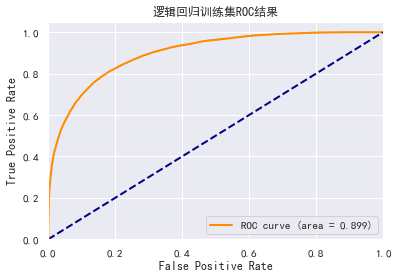

In [41]:
plot_roc(lr,X_train,y_train,'逻辑回归训练集ROC结果')

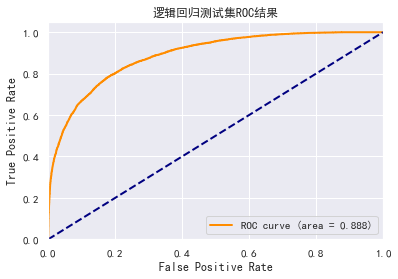

In [42]:
plot_roc(lr,X_test,y_test,'逻辑回归测试集ROC结果')

In [43]:
df = get_score(gb,'贝叶斯')
df

,指标,训练集,测试集,模型
0,AUC,0.734396,0.702900,贝叶斯
1,ACC,0.752504,0.737794,贝叶斯


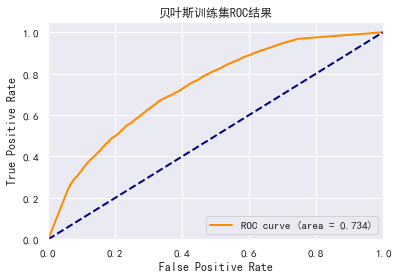

In [44]:
plot_roc(gb,X_train,y_train,'贝叶斯训练集ROC结果')

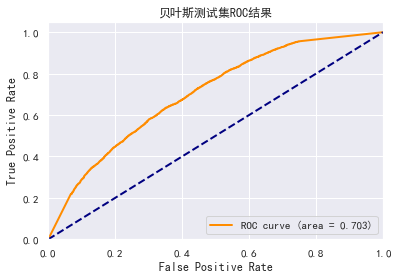

In [45]:
plot_roc(gb,X_test,y_test,'贝叶斯测试集ROC结果')

In [61]:
df = get_score(gs_rfr,'随机森林')
df

,指标,训练集,测试集,模型
0,AUC,0.938988,0.911348,随机森林
1,ACC,0.852617,0.825787,随机森林


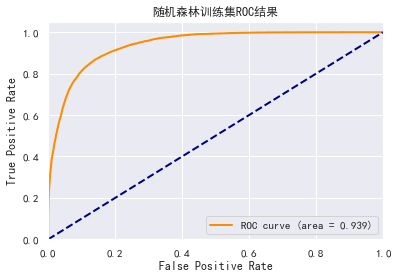

In [62]:
plot_roc(gs_rfr,X_train,y_train,'随机森林训练集ROC结果')

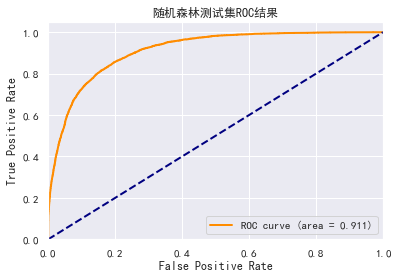

In [63]:
plot_roc(gs_rfr,X_test,y_test,'随机森林测试集ROC结果')

In [49]:
df = get_score(gs_dr,'决策树')
df

,指标,训练集,测试集,模型
0,AUC,0.879659,0.878738,决策树
1,ACC,0.830780,0.828821,决策树


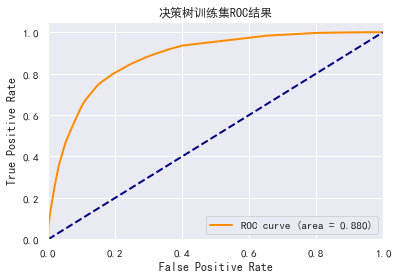

In [50]:
plot_roc(gs_dr,X_train,y_train,'决策树训练集ROC结果')

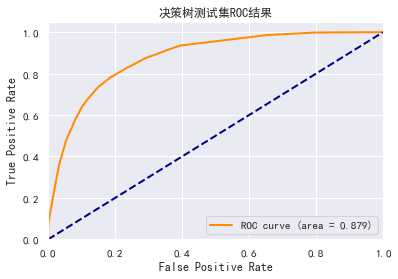

In [51]:
plot_roc(gs_dr,X_test,y_test,'决策树测试集ROC结果')